## Imports

In [29]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

from neuro_fuzzy_toolbox import ANFIS, Hybrid_learning_algorithm, EarlyStopping, get_measures

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    MaxAbsScaler,
    Normalizer,
    QuantileTransformer,
    PowerTransformer,
)
from sklearn.model_selection import train_test_split

In [32]:
from ucimlrepo import fetch_ucirepo

## Data

In [33]:
auto_mpg = fetch_ucirepo(id=9)

X = auto_mpg.data.features 
y = auto_mpg.data.targets

In [34]:
X = X.fillna(X.mean()).astype(np.float32)
y = y.astype(np.float32)

In [35]:
X

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8.0,130.0,3504.0,12.0,70.0,1.0
1,350.0,8.0,165.0,3693.0,11.5,70.0,1.0
2,318.0,8.0,150.0,3436.0,11.0,70.0,1.0
3,304.0,8.0,150.0,3433.0,12.0,70.0,1.0
4,302.0,8.0,140.0,3449.0,10.5,70.0,1.0
...,...,...,...,...,...,...,...
393,140.0,4.0,86.0,2790.0,15.6,82.0,1.0
394,97.0,4.0,52.0,2130.0,24.6,82.0,2.0
395,135.0,4.0,84.0,2295.0,11.6,82.0,1.0
396,120.0,4.0,79.0,2625.0,18.6,82.0,1.0


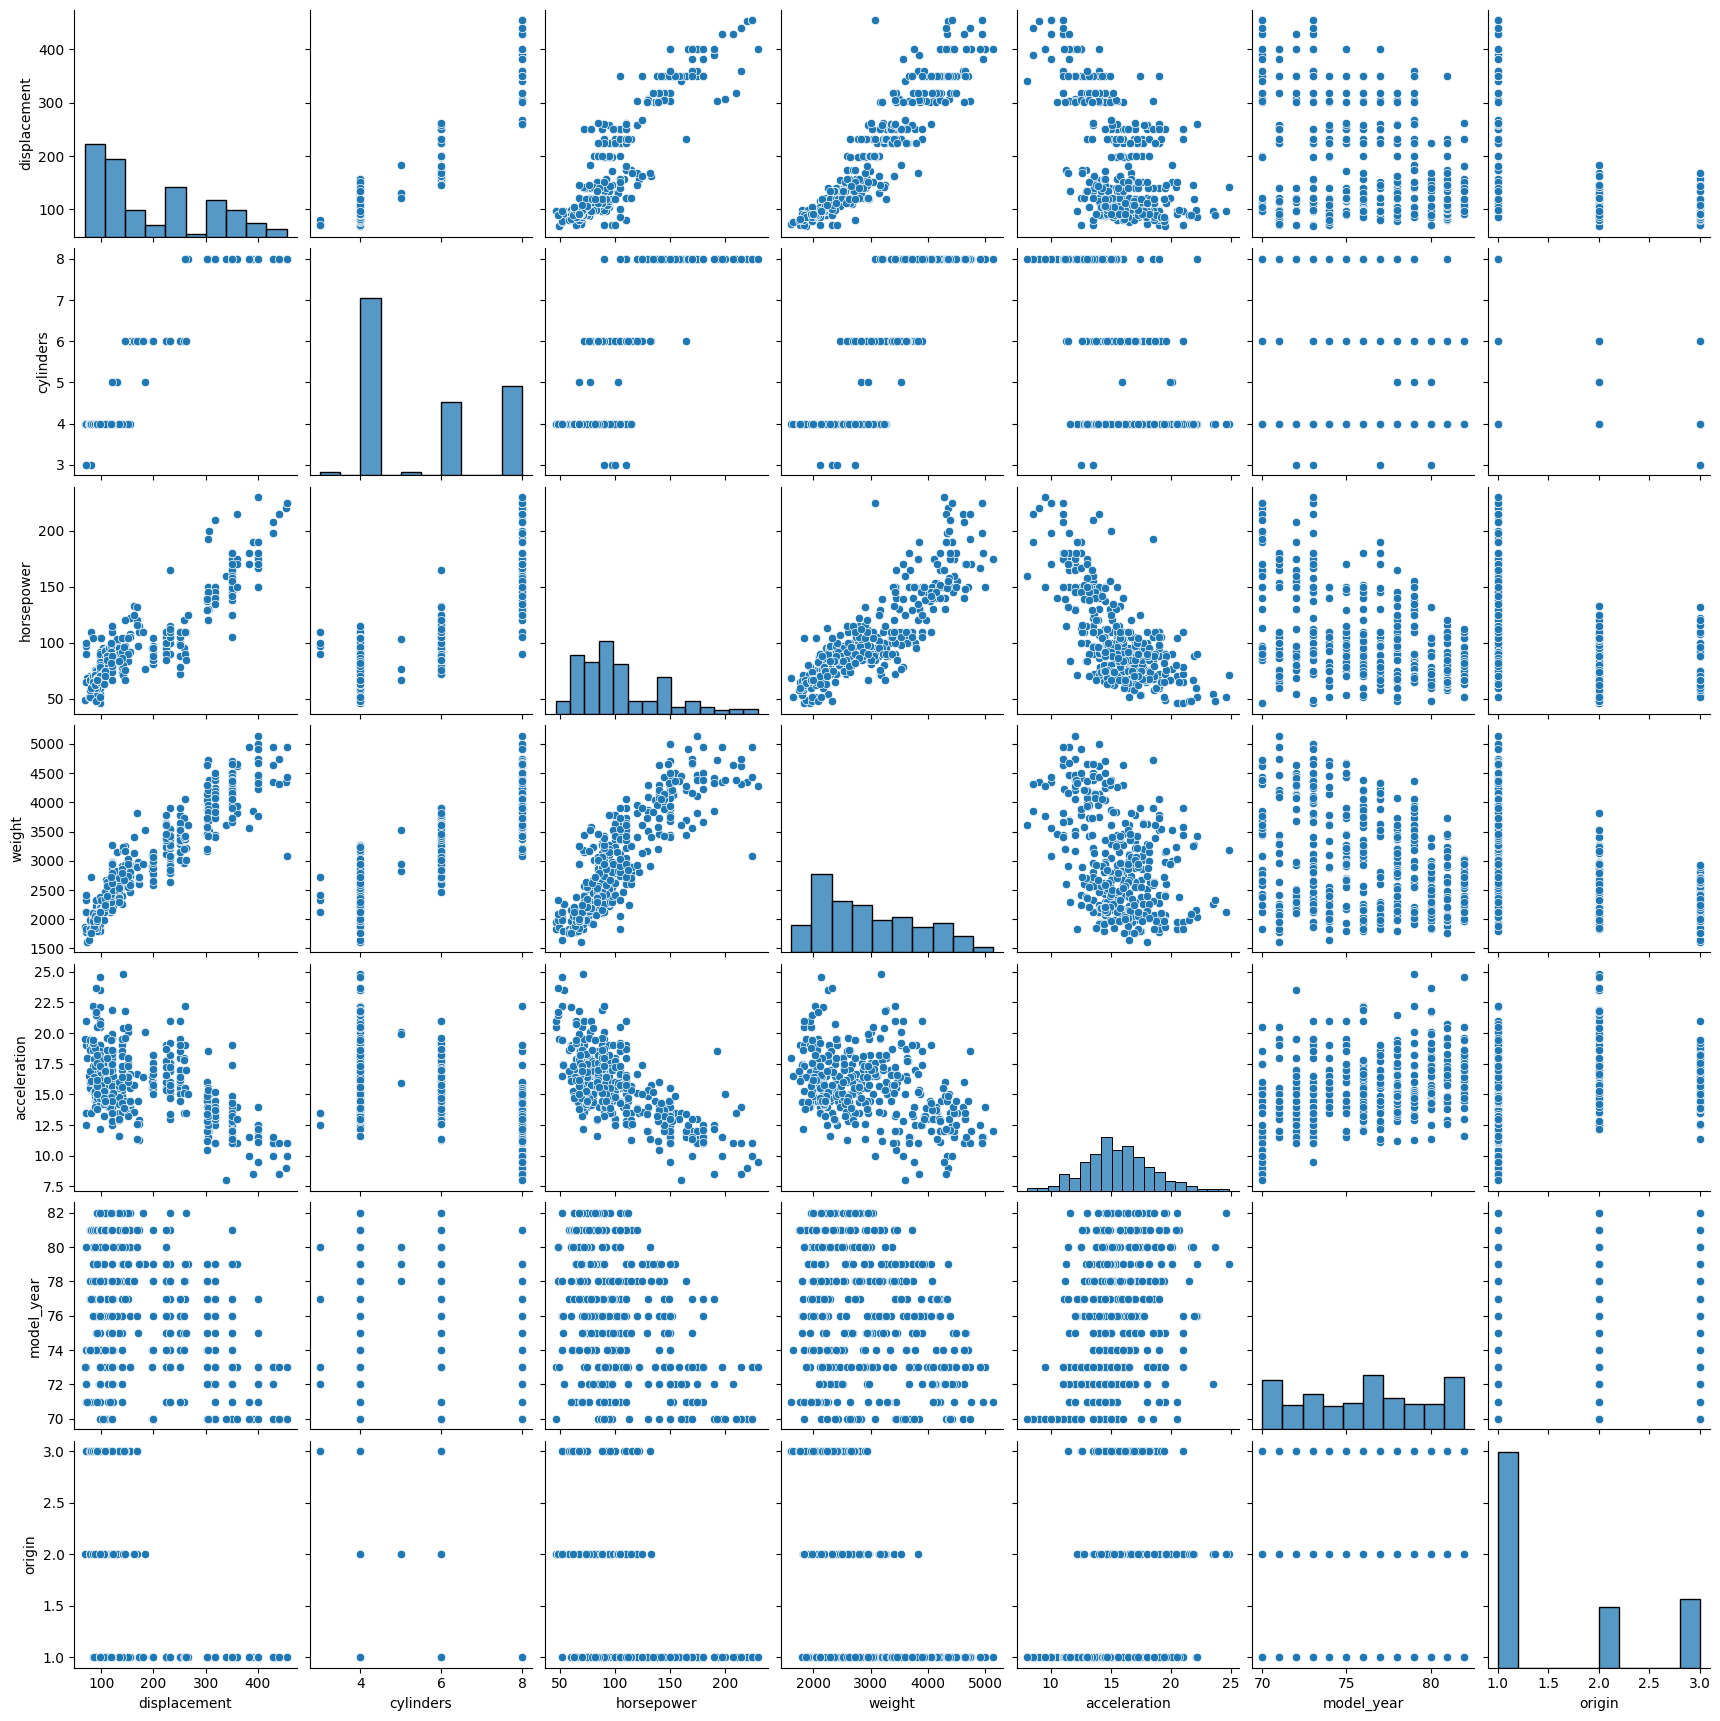

In [36]:
sns.pairplot(X)
plt.show()

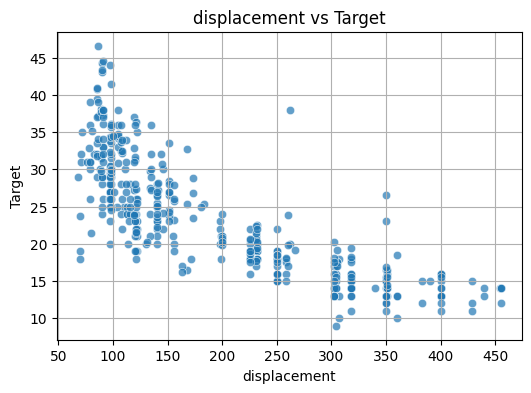

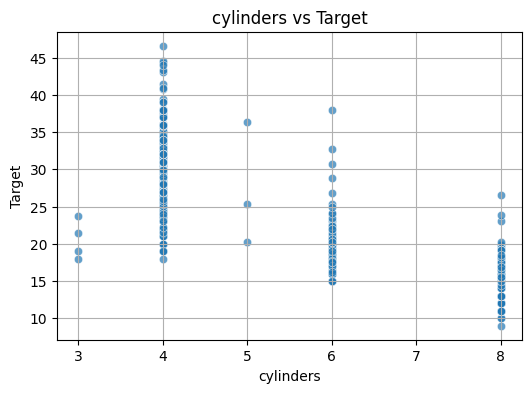

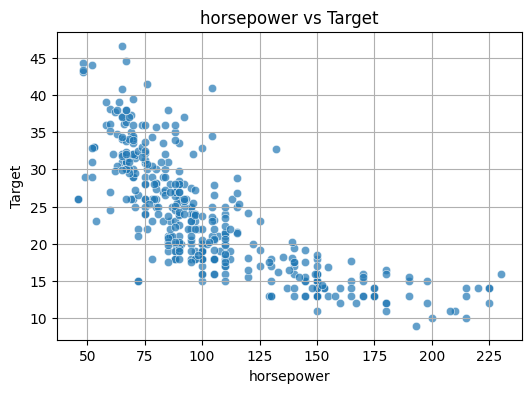

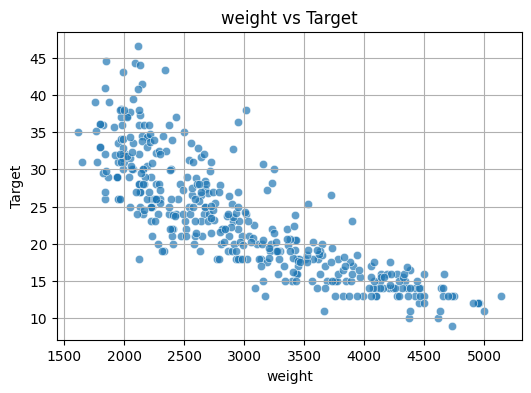

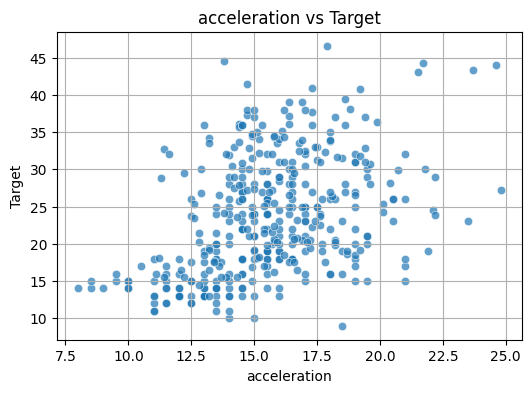

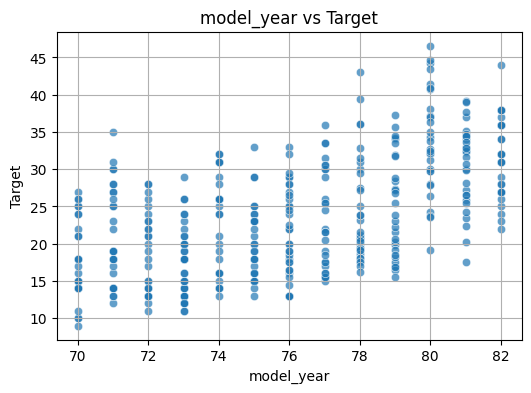

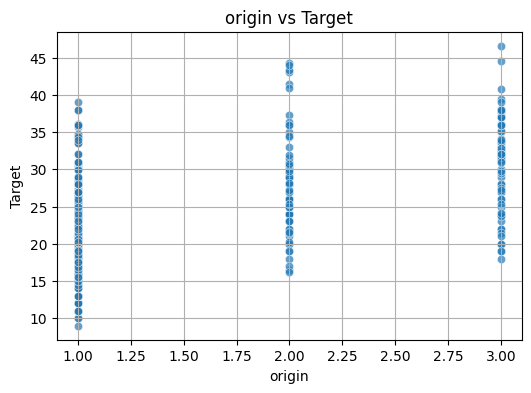

In [37]:
for column in X.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X[column], y=y.squeeze(), alpha=0.7)
    plt.xlabel(column)
    plt.ylabel('Target')
    plt.title(f'{column} vs Target')
    plt.grid(True)
    plt.show()

In [38]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float32
 1   cylinders     398 non-null    float32
 2   horsepower    398 non-null    float32
 3   weight        398 non-null    float32
 4   acceleration  398 non-null    float32
 5   model_year    398 non-null    float32
 6   origin        398 non-null    float32
dtypes: float32(7)
memory usage: 11.0 KB


In [39]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [40]:
#scaler = MinMaxScaler(feature_range=(-1, 1))
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

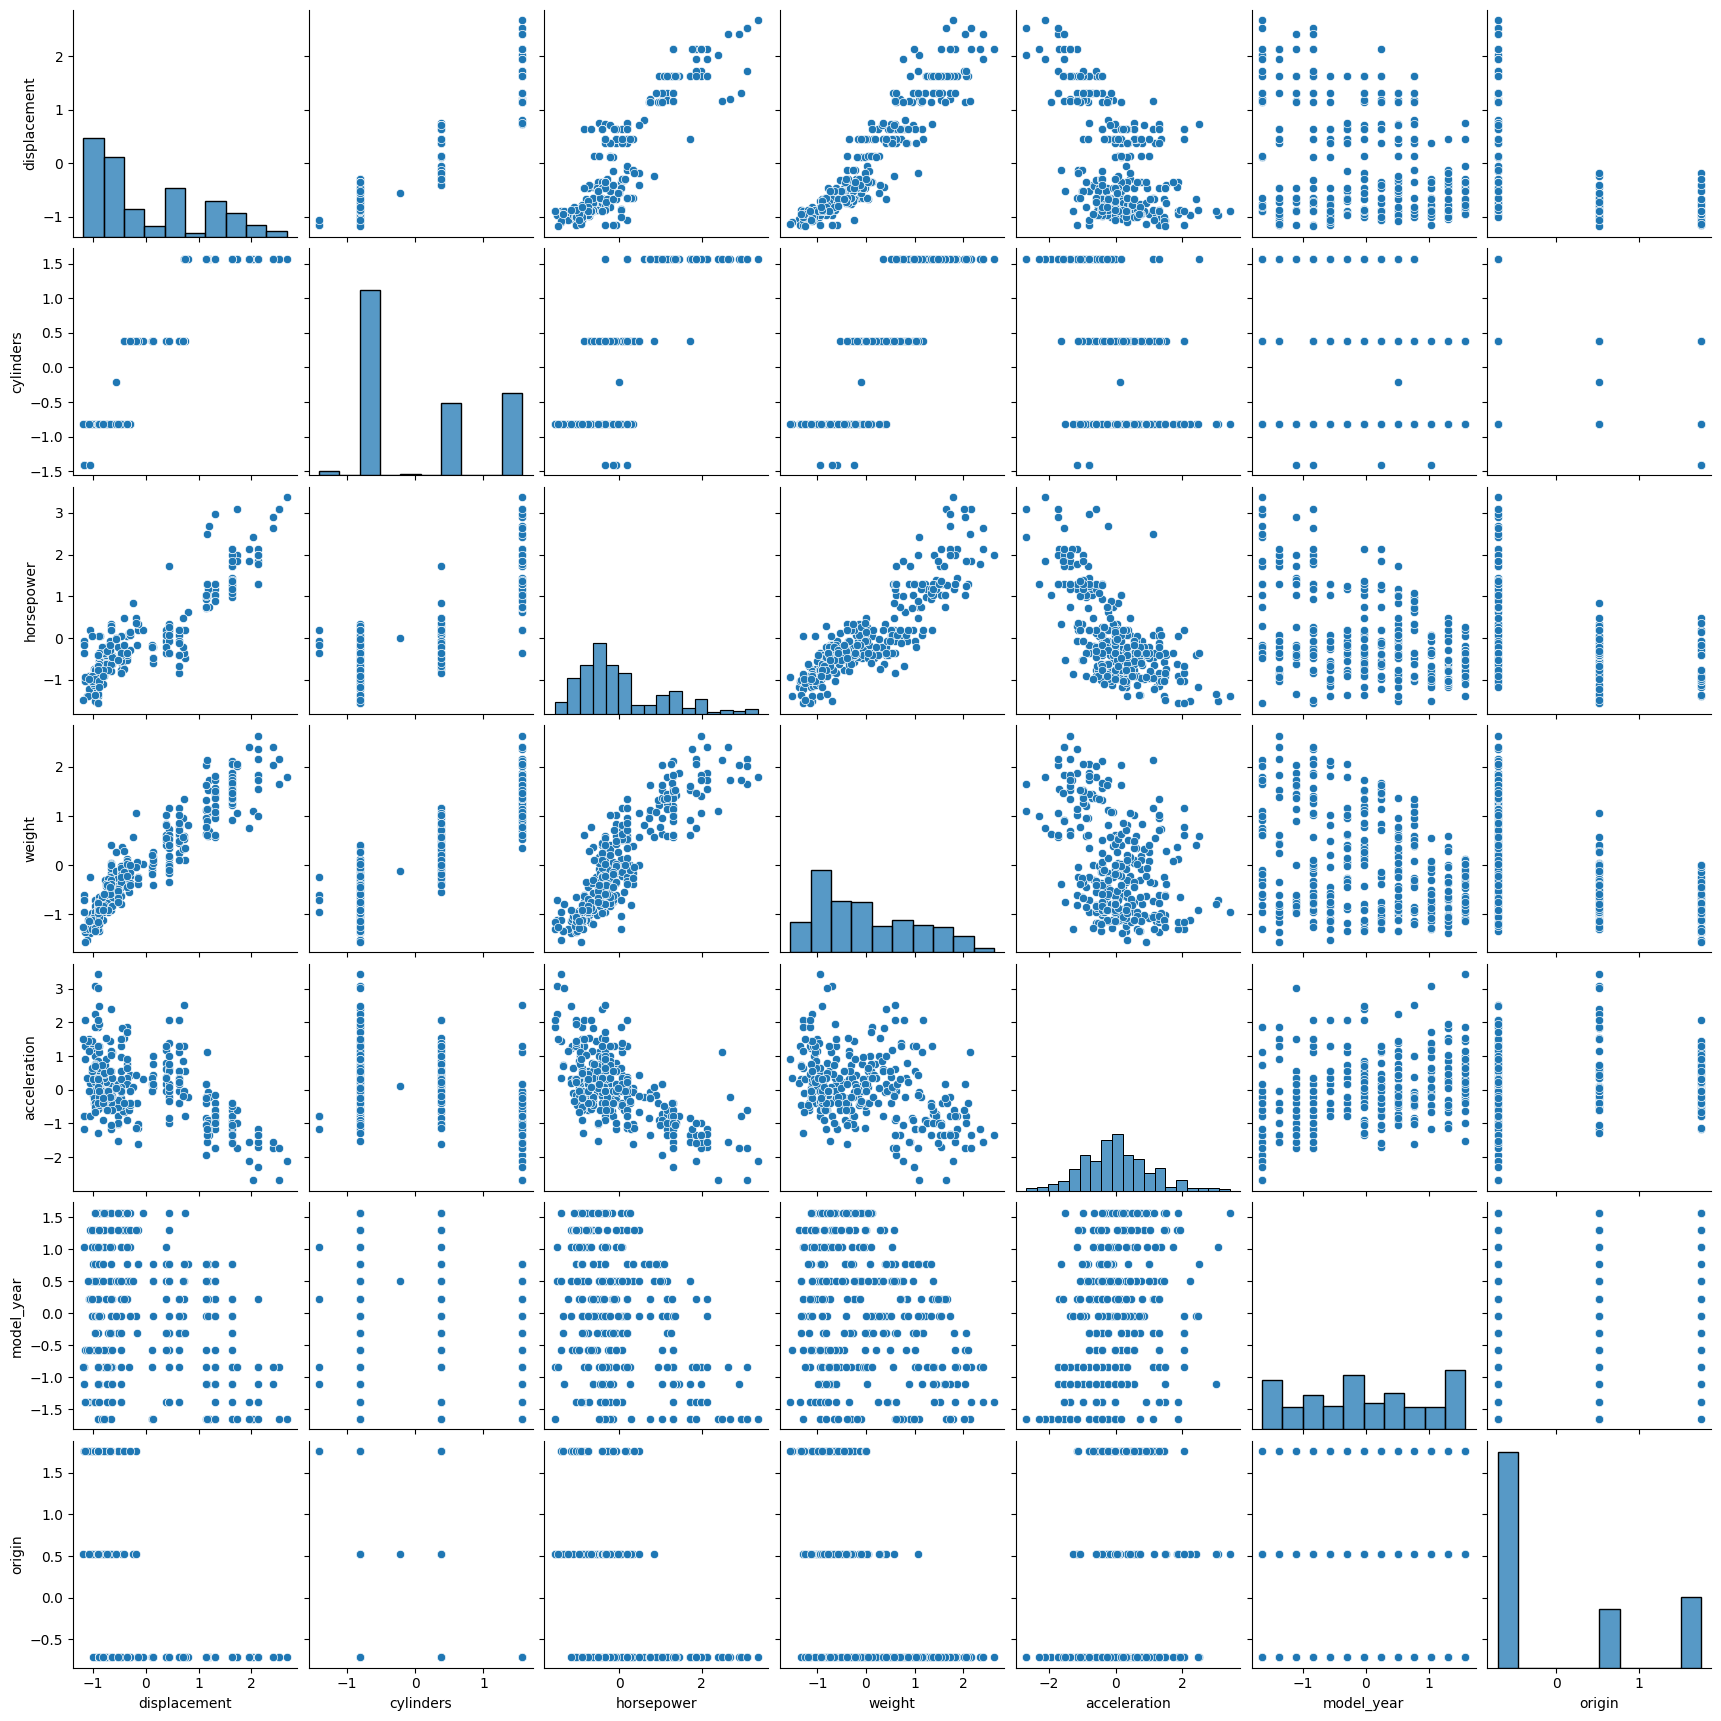

In [41]:
scaled_df = pd.DataFrame(x_train, columns=X.columns)
sns.pairplot(scaled_df)
plt.show()

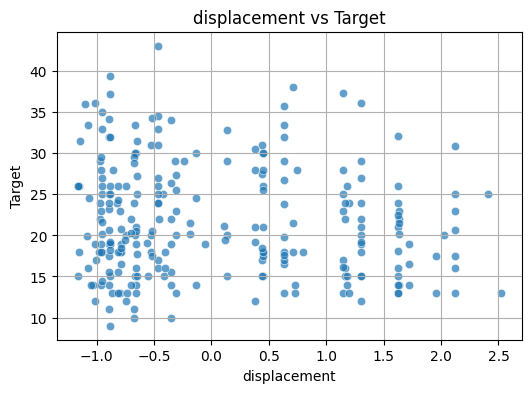

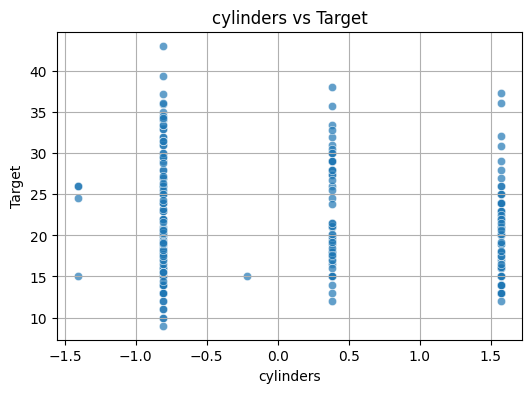

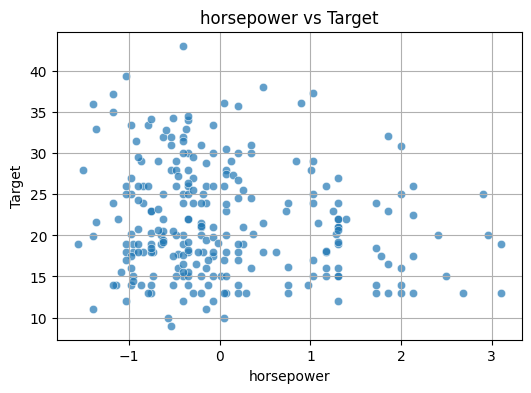

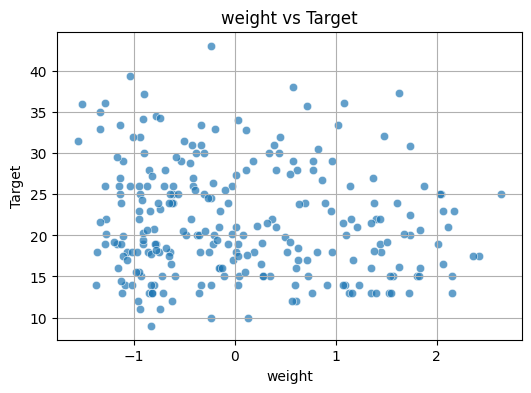

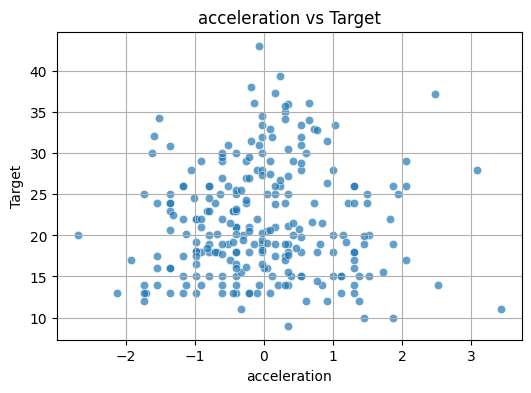

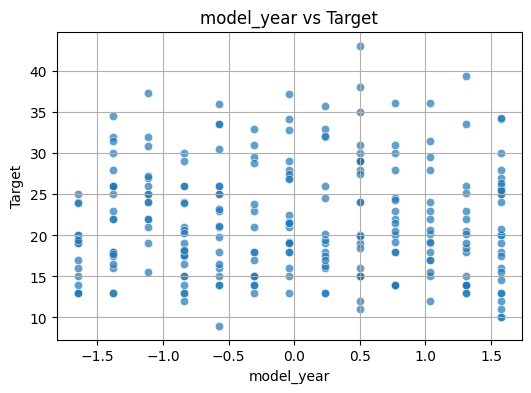

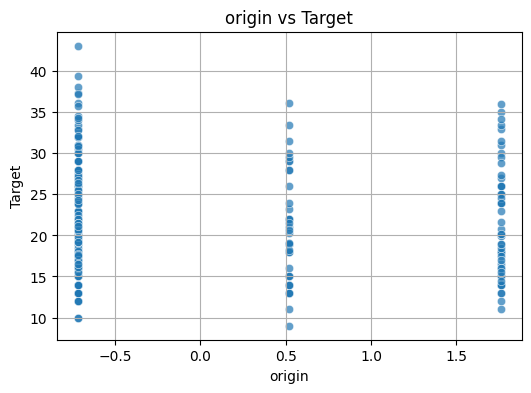

In [42]:
for column in scaled_df.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=scaled_df[column], y=y_train.squeeze(), alpha=0.7)
    plt.xlabel(column)
    plt.ylabel('Target')
    plt.title(f'{column} vs Target')
    plt.grid(True)
    plt.show()

In [31]:
x_train.shape, x_test.shape

((318, 7), (80, 7))

In [12]:
x_train = torch.from_numpy(x_train)
x_test = torch.from_numpy(x_test)
y_train = torch.from_numpy(y_train.values).squeeze()
y_test = torch.from_numpy(y_test.values).squeeze()

In [13]:
x_train.dtype, y_train.dtype

(torch.float32, torch.float32)

In [14]:
loader = data.DataLoader(data.TensorDataset(x_train, y_train), batch_size = 4, shuffle = True)
x_trainset = loader.dataset.tensors[0]
y_trainset = loader.dataset.tensors[1]

## Model & Training

In [15]:
model = ANFIS(
    mf_distribution=[3, 3, 2, 3, 3, 2, 3],
    outputs=1
)

In [16]:
model.init_premises(x_train)

In [17]:
model.show_premises_structure()

      a (x0)  b (x0)        c (x0)  a (x1)  b (x1)  c (x1)  a (x2)  b (x2)  \
MF 0     0.5     4.0 -1.000000e+00     0.5     4.0    -1.0     1.0     4.0   
MF 1     0.5     4.0  5.960464e-08     0.5     4.0     0.0     1.0     4.0   
MF 2     0.5     4.0  1.000000e+00     0.5     4.0     1.0     NaN     NaN   
MF 3     NaN     NaN           NaN     NaN     NaN     NaN     NaN     NaN   

      c (x2)    a (x3)  ...    c (x3)  a (x4)  b (x4)        c (x4)    a (x5)  \
MF 0    -1.0  0.333333  ... -1.000000     0.5     4.0 -1.000000e+00  0.333333   
MF 1     1.0  0.333333  ... -0.333333     0.5     4.0  5.960464e-08  0.333333   
MF 2     NaN  0.333333  ...  0.333333     0.5     4.0  1.000000e+00  0.333333   
MF 3     NaN  0.333333  ...  1.000000     NaN     NaN           NaN  0.333333   

      b (x5)    c (x5)  a (x6)  b (x6)  c (x6)  
MF 0     4.0 -1.000000     0.5     4.0    -1.0  
MF 1     4.0 -0.333333     0.5     4.0     0.0  
MF 2     4.0  0.333333     0.5     4.0     1.0  
MF 3   

In [18]:
model.get_premises()

[tensor([[ 5.0000e-01,  4.0000e+00, -1.0000e+00],
         [ 5.0000e-01,  4.0000e+00,  5.9605e-08],
         [ 5.0000e-01,  4.0000e+00,  1.0000e+00]]),
 tensor([[ 0.5000,  4.0000, -1.0000],
         [ 0.5000,  4.0000,  0.0000],
         [ 0.5000,  4.0000,  1.0000]]),
 tensor([[ 1.,  4., -1.],
         [ 1.,  4.,  1.]]),
 tensor([[ 0.3333,  4.0000, -1.0000],
         [ 0.3333,  4.0000, -0.3333],
         [ 0.3333,  4.0000,  0.3333],
         [ 0.3333,  4.0000,  1.0000]]),
 tensor([[ 5.0000e-01,  4.0000e+00, -1.0000e+00],
         [ 5.0000e-01,  4.0000e+00,  5.9605e-08],
         [ 5.0000e-01,  4.0000e+00,  1.0000e+00]]),
 tensor([[ 0.3333,  4.0000, -1.0000],
         [ 0.3333,  4.0000, -0.3333],
         [ 0.3333,  4.0000,  0.3333],
         [ 0.3333,  4.0000,  1.0000]]),
 tensor([[ 0.5000,  4.0000, -1.0000],
         [ 0.5000,  4.0000,  0.0000],
         [ 0.5000,  4.0000,  1.0000]])]

In [19]:
loss_fn = nn.functional.mse_loss

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01, 'eps':1e-2}

#optimizer = torch.optim.Adam
#params = {'lr': 0.001, 'eps':1e-4}

early_stopping = EarlyStopping(patience=10, delta=0.01)

trainer = Hybrid_learning_algorithm(
    epochs=100,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=0.3,
    early_stopping=early_stopping
)

In [20]:
trainer(model, loader, verbose=True)

Epoch:   1/100 - loss: 549.185974 - validation loss: 578.481079
Epoch:   2/100 - loss: 543.429932 - validation loss: 575.251831
Epoch:   3/100 - loss: 478.207916 - validation loss: 531.975464
Epoch:   4/100 - loss: 491.415344 - validation loss: 544.431763
Epoch:   5/100 - loss: 488.674652 - validation loss: 542.335571
Epoch:   6/100 - loss: 492.000488 - validation loss: 539.283203
Epoch:   7/100 - loss: 463.532928 - validation loss: 515.550171
Epoch:   8/100 - loss: 461.044708 - validation loss: 508.417450
Epoch:   9/100 - loss: 453.779572 - validation loss: 495.005859
Epoch:  10/100 - loss: 446.307922 - validation loss: 473.526886
Epoch:  11/100 - loss: 345.907806 - validation loss: 349.188324
Epoch:  12/100 - loss: 286.854797 - validation loss: 285.896149
Epoch:  13/100 - loss: 284.210266 - validation loss: 293.116638
Epoch:  14/100 - loss: 169.773041 - validation loss: 164.942490
Epoch:  15/100 - loss: 120.962387 - validation loss: 106.194405
Epoch:  16/100 - loss: 89.969719 - valid

RuntimeError: false INTERNAL ASSERT FAILED at "../aten/src/ATen/native/BatchLinearAlgebra.cpp":1538, please report a bug to PyTorch. torch.linalg.lstsq: Argument 4 has illegal value. Most certainly there is a bug in the implementation calling the backend library.

In [13]:
model.show_premises_structure()

                a (x0)    b (x0)    c (x0)    a (x1)    b (x1)    c (x1)
Fuzzy rule 0  0.389986  1.660402 -0.727313  0.316038  1.491838  0.285184
Fuzzy rule 1  0.497173  1.883862 -0.462154  0.900963  1.236224  0.750950
Fuzzy rule 2  0.251974  1.515619 -0.017475  0.278889  1.037542  0.641393
Fuzzy rule 3  0.582398  1.765327  0.661562  0.787842  1.587424  0.826791
Fuzzy rule 4  0.455590  1.971654  0.314346  0.253807  1.359445  0.092831
Fuzzy rule 5  0.856704  1.094049  0.163136  0.704981  1.691704  0.127490


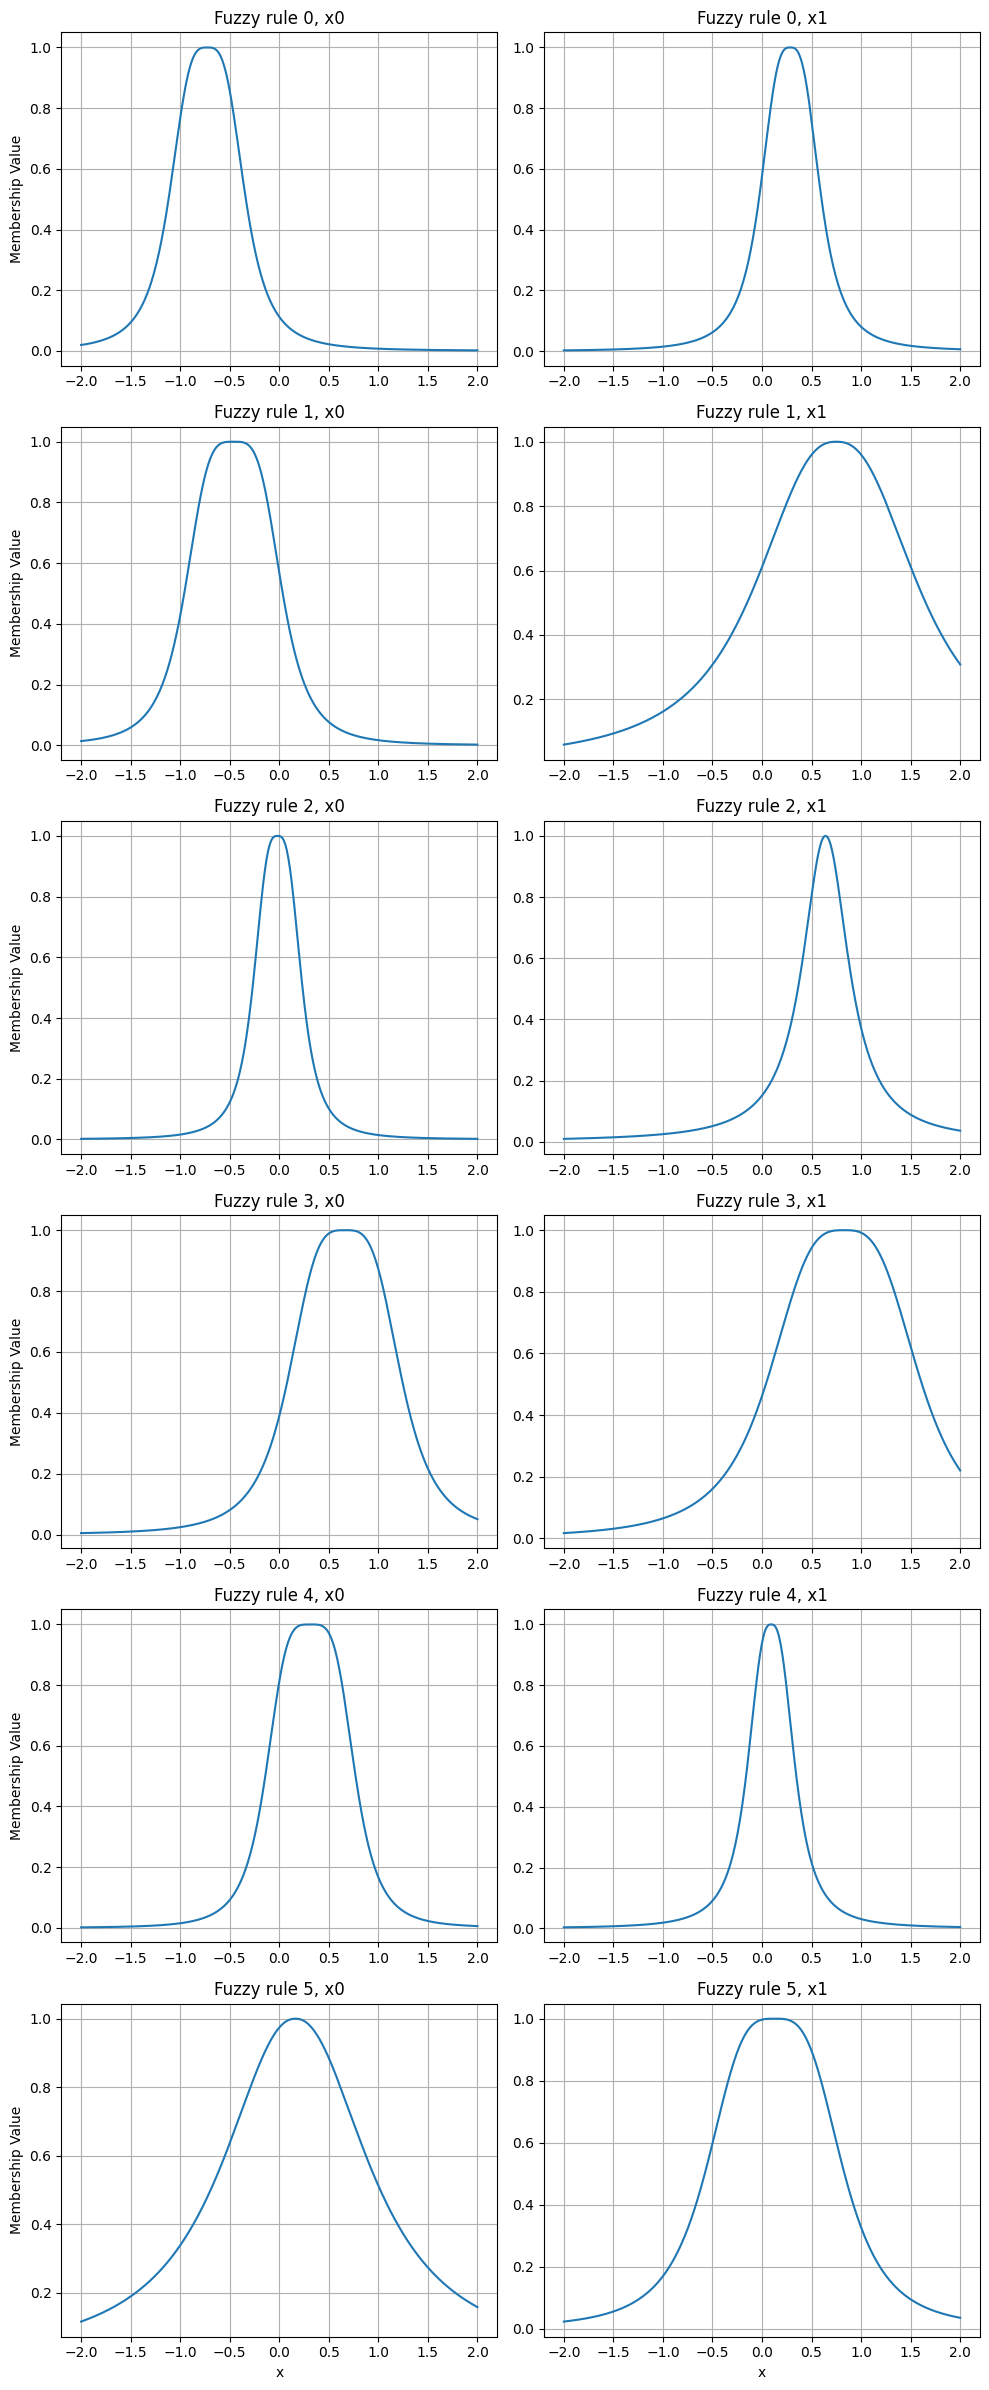

In [14]:
model.plot_premises()

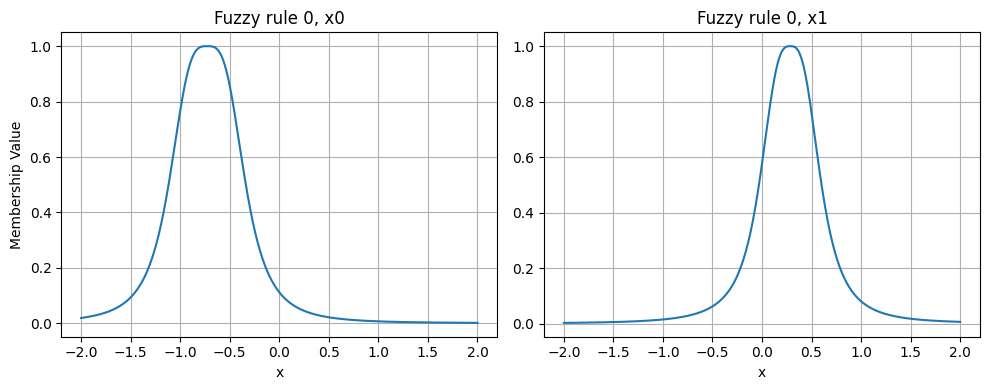

In [15]:
model.plot_premises(fuzzy_rule = 0)

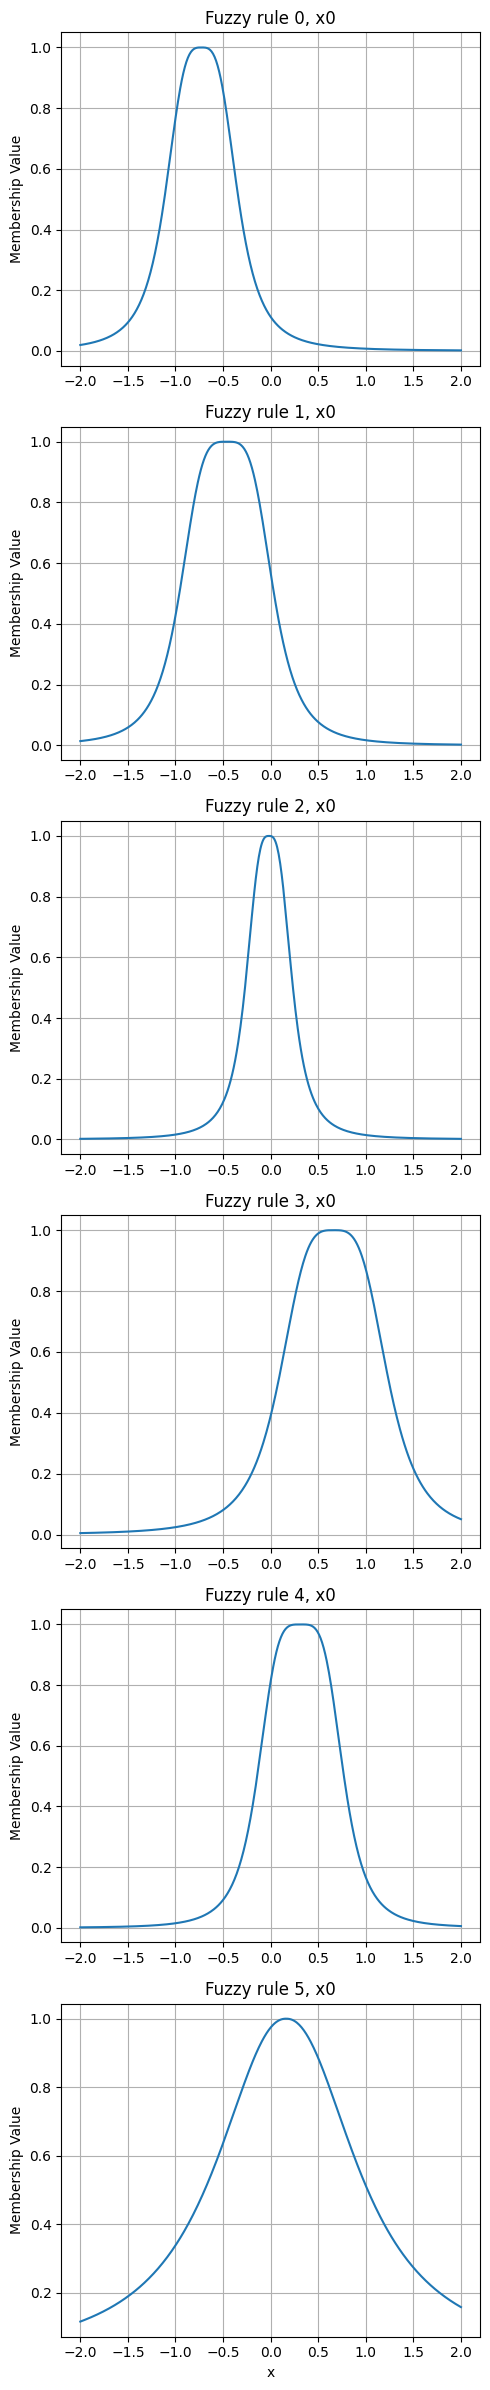

In [16]:
model.plot_premises(input_dim=0)

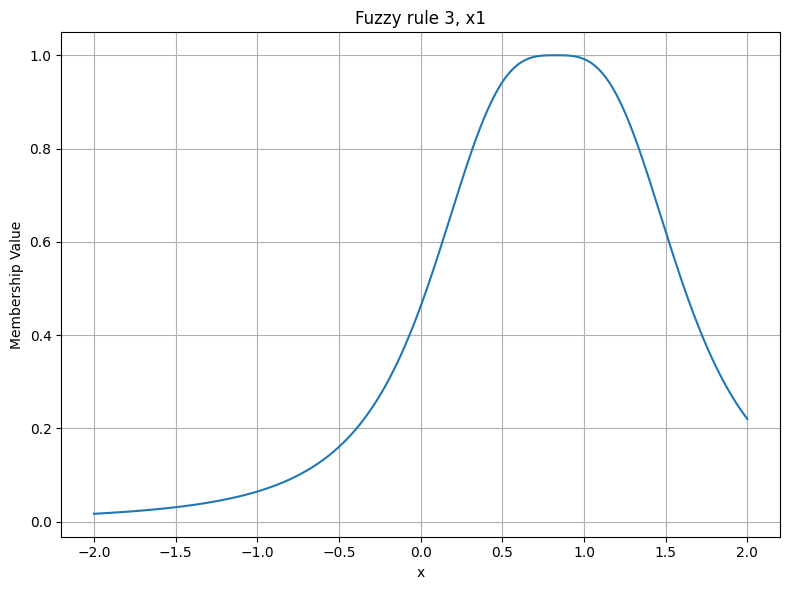

In [17]:
model.plot_premises(fuzzy_rule=3, input_dim=1)

In [18]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
Fuzzy rule 0,0.389986,1.660402,-0.727313,0.316038,1.491838,0.285184
Fuzzy rule 1,0.497173,1.883862,-0.462154,0.900963,1.236224,0.750950
Fuzzy rule 2,0.251974,1.515619,-0.017475,0.278889,1.037542,0.641393
Fuzzy rule 3,0.582398,1.765327,0.661562,0.787842,1.587424,0.826791
Fuzzy rule 4,0.455590,1.971654,0.314346,0.253807,1.359445,0.092831
Fuzzy rule 5,0.856704,1.094049,0.163136,0.704981,1.691704,0.127490


In [19]:
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.08390044989928047
RMSE: 0.2896557437705672
MAE: 0.2178642820153569
R2: 0.9775153601504464
MAPE: 80.50770539074234


In [20]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.08997107301003468
RMSE: 0.2999517844754965
MAE: 0.2282867111959659
R2: 0.9755453615047155
MAPE: 3.259693731372865


In [21]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
Fuzzy rule 0,0.389986,1.660402,-0.727313,0.316038,1.491838,0.285184
Fuzzy rule 1,0.497173,1.883862,-0.462154,0.900963,1.236224,0.750950
Fuzzy rule 2,0.251974,1.515619,-0.017475,0.278889,1.037542,0.641393
Fuzzy rule 3,0.582398,1.765327,0.661562,0.787842,1.587424,0.826791
Fuzzy rule 4,0.455590,1.971654,0.314346,0.253807,1.359445,0.092831
Fuzzy rule 5,0.856704,1.094049,0.163136,0.704981,1.691704,0.127490


In [22]:
model.consequents_structure[0]

,c0 (x0),c1 (x1),c2
rule 1,1.558793e+06,7.551435e+03,1.308375e+06
rule 2,-2.990205e+07,4.169331e+06,7.189571e+06
rule 3,-9.890115e+05,-2.953187e+05,8.556231e+05
rule 4,2.897503e+07,-2.954255e+06,-7.473164e+06
rule 5,2.894440e+06,-1.708200e+05,1.314849e+06
rule 6,1.021202e+06,3.364789e+05,-3.275950e+06
rule 7,3.888567e+05,-2.934454e+03,-7.414666e+04
rule 8,1.112588e+07,-9.525724e+05,5.427267e+05
rule 9,6.044621e+05,6.114200e+04,-4.786629e+04
rule 10,-1.032448e+07,6.850716e+05,-2.750117e+05
